In [19]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
%matplotlib inline
import  matplotlib.pyplot as plt

In [20]:

test= pd.read_excel('../dataset/pre_test.xlsx')

In [21]:
# X_columns = [col for col in test.columns if col not in ['time','AQ']]
Y_columns =['AQ']

In [22]:

# x_test=test[X_columns]
y_test=test[Y_columns]

In [23]:
import joblib
import os

file_dir = "..\secondgoaldata"
mpkl_name=[]
mpkl_path=[]
# 获得文件完整路径
for root, dirs, files in os.walk(file_dir):
    for name in files:
        mpkl_name.append(str(name)[:-5])
        mpkl_path.append(os.path.join(root, name))

import re
def sortkey(element):
    a=re.findall("\d+",element)
    return int(*a)


mpkl_name.sort(key=sortkey, reverse=False)
print(mpkl_name)

mpkl_path.sort(key=sortkey, reverse=False)
print(mpkl_path)


['m1_logis', 'm2_svm', 'm3_dt', 'm4_knn', 'm5_ANN', 'm6_LSTM', 'm7_ridge', 'm8_lasso', 'm9_Huber', 'm10_bayes', 'm11_ard', 'm12_RF', 'm13_LGBM', 'm14_GBDT', 'm15_XGB']
['..\\secondgoaldata\\m1_logis.xlsx', '..\\secondgoaldata\\m2_svm.xlsx', '..\\secondgoaldata\\m3_dt.xlsx', '..\\secondgoaldata\\m4_knn.xlsx', '..\\secondgoaldata\\m5_ANN.xlsx', '..\\secondgoaldata\\m6_LSTM.xlsx', '..\\secondgoaldata\\m7_ridge.xlsx', '..\\secondgoaldata\\m8_lasso.xlsx', '..\\secondgoaldata\\m9_Huber.xlsx', '..\\secondgoaldata\\m10_bayes.xlsx', '..\\secondgoaldata\\m11_ard.xlsx', '..\\secondgoaldata\\m12_RF.xlsx', '..\\secondgoaldata\\m13_LGBM.xlsx', '..\\secondgoaldata\\m14_GBDT.xlsx', '..\\secondgoaldata\\m15_XGB.xlsx']


In [24]:
loss_evl=pd.DataFrame(columns=['modelname','MAPE', 'R2', 'RMSE'], index=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])
loss_evl

,modelname,MAPE,R2,RMSE
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN


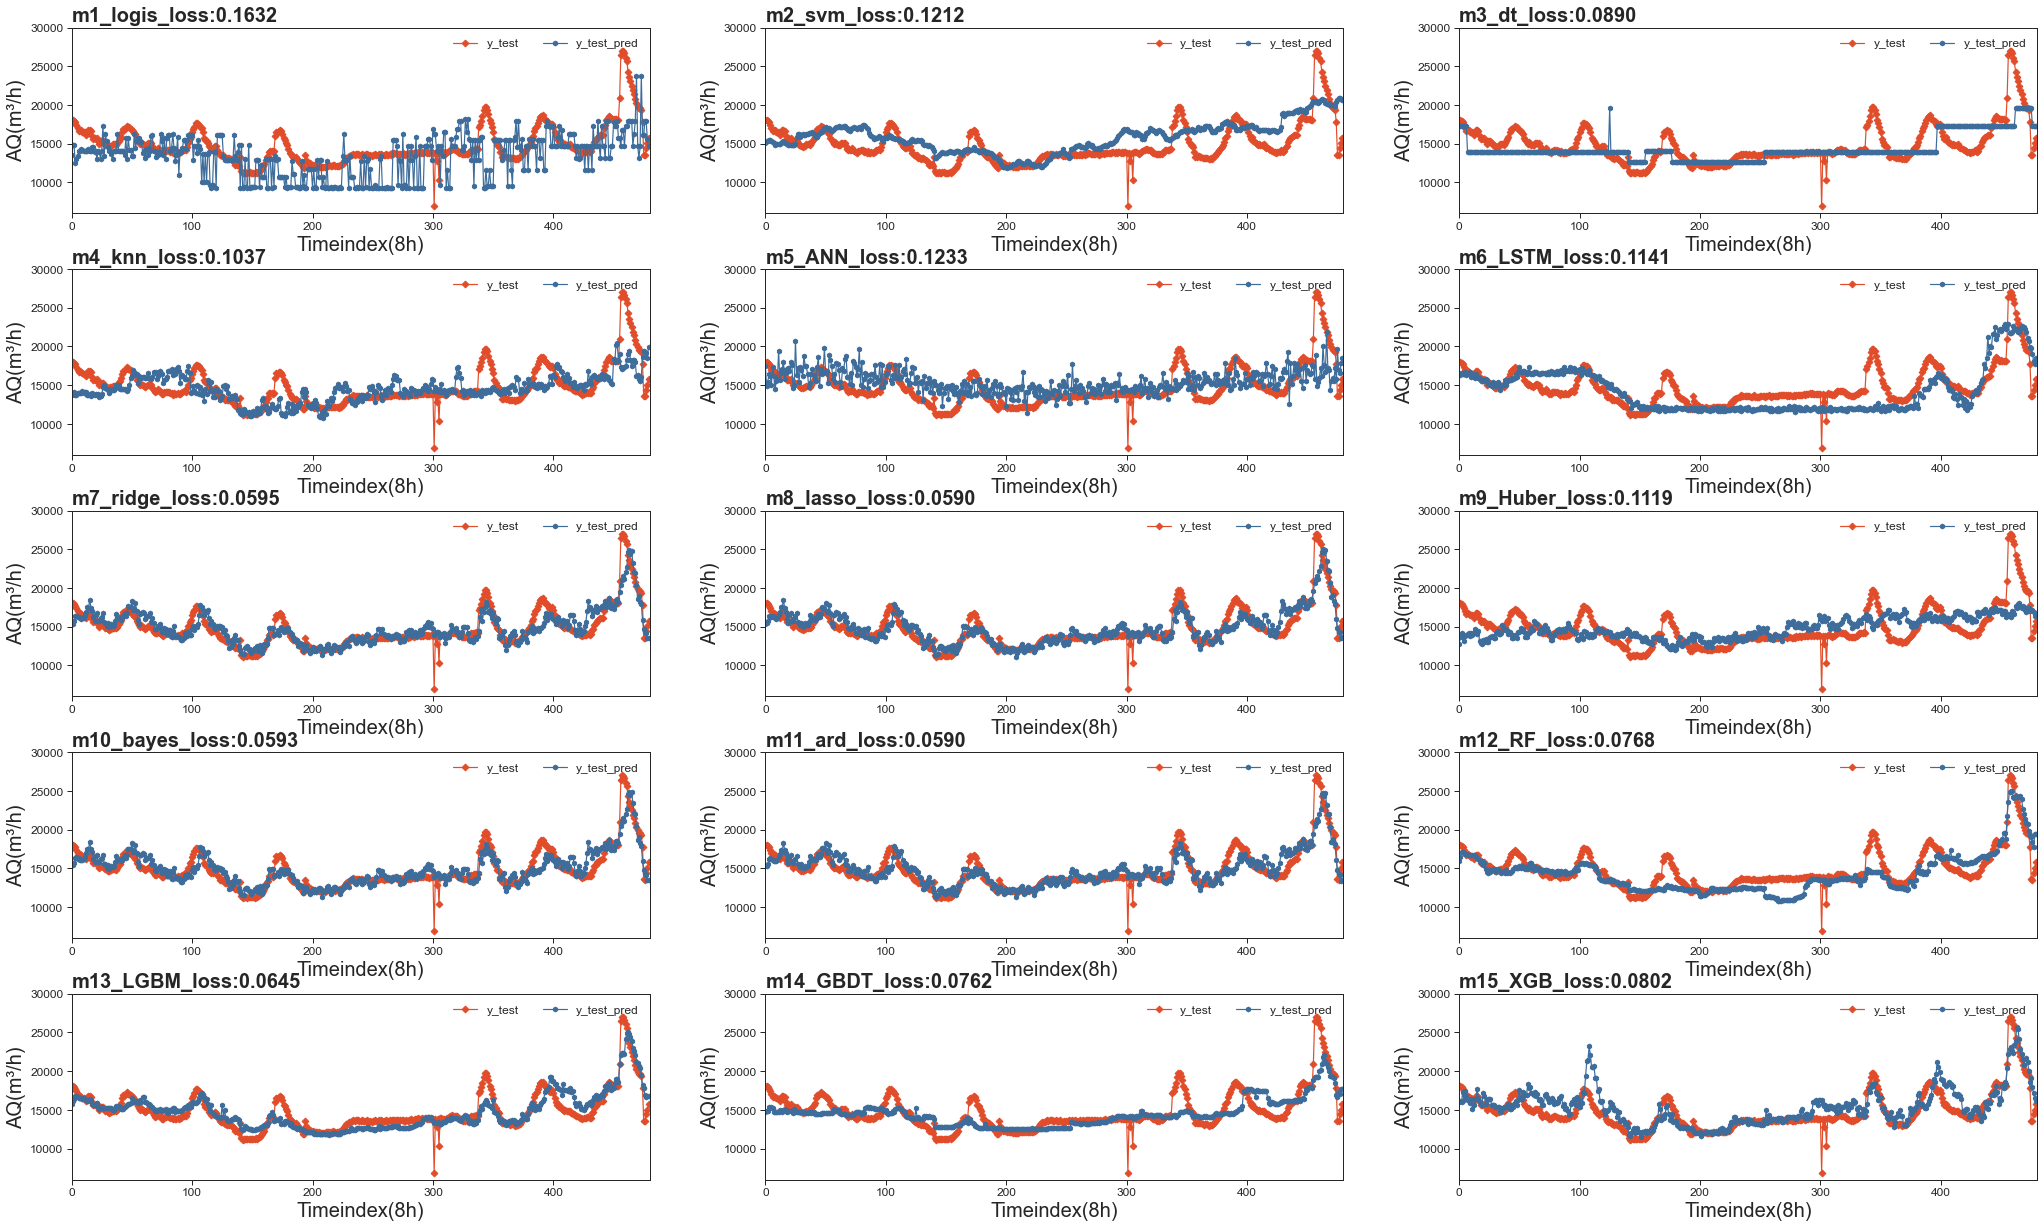

In [25]:
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import r2_score as r2

from sklearn.metrics import mean_squared_error as mse



fig,axes=plt.subplots(5,3,figsize=(39,20))

a=1
dict_axes={}
for i in range(5):
    for j in range(3):
        dict_axes[a]=[i,j]
        a=a+1

def plttest(mpkl_name,num):
    i=num-1
    name=str(mpkl_name[i])
    pdata=pd.read_excel(mpkl_path[i])

    y_pred = pdata['ytest'].dropna(axis=0)
    loss=mape(y_test, y_pred)
    r2loss=r2(y_test, y_pred)
    rmse=mse(y_test, y_pred)**0.5
    modelname=f'{name}'
    loss_evl.iloc[i,0]=modelname
    loss_evl.iloc[i,1]=loss
    loss_evl.iloc[i,2]=r2loss
    loss_evl.iloc[i,3]=rmse

    test_index=test.index
    y_test_pred=pdata['ytest'].dropna(axis=0)
    y_test_pred=pd.DataFrame(columns=['AQ'],data=np.array(y_test_pred))


    ax=axes[dict_axes[num][0]][dict_axes[num][1]]
    fig.subplots_adjust(left=0.1, right=0.8, bottom=0.1, top=0.9, wspace=0.2, hspace=0.3)

    x=test_index
    y1=y_test['AQ']
    y2=y_test_pred['AQ']
    lns1=ax.plot(x,y1,label='y_test',marker='D',markevery=1, color='#E14D2A')
    lns2=ax.plot(x,y2,label='y_test_pred',marker='h',markevery=1, color='#3E6D9C')
    ax.tick_params(labelsize=12)
    ax.set_xlim(0,480,1)
    ax.set_ylim(6000,30000, 5000)
    ax.set_xlabel('Timeindex(8h)',size=20)
    ax.set_ylabel('AQ(m³/h)',size=20)
    ax.set_title(f'{name}_loss:{loss:.4f}',size=20,fontweight='bold',loc='left')
    lns = lns1+lns2
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc=1,fontsize=12,ncol=2,frameon=False)

plttest(mpkl_name,1)
plttest(mpkl_name,2)
plttest(mpkl_name,3)
plttest(mpkl_name,4)
plttest(mpkl_name,5)
plttest(mpkl_name,6)
plttest(mpkl_name,7)
plttest(mpkl_name,8)
plttest(mpkl_name,9)
plttest(mpkl_name,10)
plttest(mpkl_name,11)
plttest(mpkl_name,12)
plttest(mpkl_name,13)
plttest(mpkl_name,14)
plttest(mpkl_name,15)



In [26]:
loss_evl

,modelname,MAPE,R2,RMSE
0,m1_logis,0.163219,-0.645928,3200.894446
1,m2_svm,0.121169,0.229528,2190.001833
2,m3_dt,0.089017,0.306998,2076.984565
3,m4_knn,0.103682,0.199458,2232.327909
4,m5_ANN,0.12333,0.068916,2407.467186
5,m6_LSTM,0.114117,0.23412,2183.465045
6,m7_ridge,0.059548,0.734612,1285.306053
7,m8_lasso,0.058989,0.743609,1263.331222
8,m9_Huber,0.11189,0.171298,2271.251272
9,m10_bayes,0.059279,0.735674,1282.732508


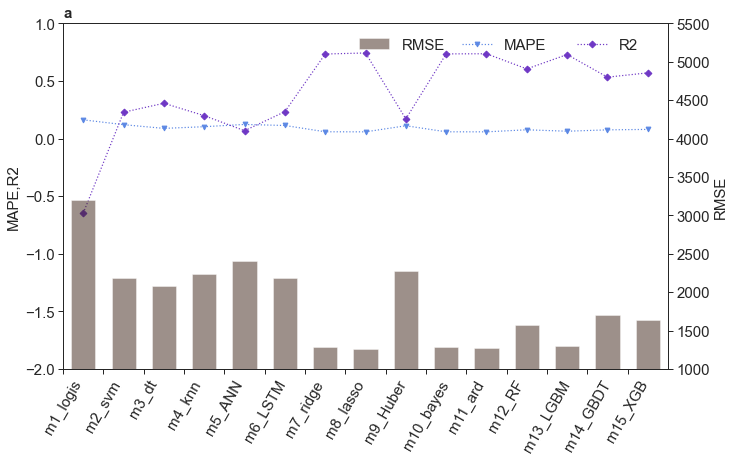

In [27]:
import seaborn as sns
sns.set(context='paper', style='ticks')


fig,axes=plt.subplots(1,1,figsize=(12,6))
ax1=axes

fig.subplots_adjust(left=0.1, right=0.8, bottom=0.1, top=0.9, wspace=0.2, hspace=0.3)
xran=[i-0.5 for i in range(15)]


x=loss_evl.index

y1=loss_evl['MAPE']
y2=loss_evl['R2']
y3=loss_evl['RMSE']
plt.xticks(ticks=xran,labels=loss_evl['modelname'],rotation=60,fontsize=15)
plt.yticks(rotation=0,fontsize=15)
lns1=ax1.plot(x,y1,label='MAPE',marker='v',markevery=1, color='#5C88E4',linestyle='dotted')

lns2=ax1.plot(x,y2,label='R2',marker='D',markevery=1, color='#6F38C5',linestyle='dotted')
# darkorange
# royalblue
ax_r =ax1.twinx()
lns3=ax_r.bar(x,y3,label='RMSE',width=0.6,color='#3C2317',alpha=0.5)
plt.legend(loc=(0.48,0.9),fontsize=15,frameon=False)
plt.yticks(rotation=0,fontsize=15)



# plt.xticks(rotation=45,labelsize=12)
# # ax1.tick_params(rotation=45,labelsize=12)
# ax_r.tick_params(labelsize=12)

ax1.set_xlim(-0.5,14.5,1)
ax1.set_ylim(-2,1, 0.5)
ax_r.set_ylim(1000,5500, 500)
# ax1.set_xlabel('modelname',size=30)
ax1.set_ylabel('MAPE,R2',size=15)
ax_r.set_ylabel('RMSE',size=15)
ax1.set_title('a',size=15,fontweight='bold',loc='left')
lns = lns1+lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=(0.65,0.9),fontsize=15,ncol=2,frameon=False)

